# vertex-wise plotting from 3D volumes

in this tutorial, you will see how to use yabplot to project a continuous 3D volume onto a cortical surface and visualize it vertex-wise.

**why project to the surface?**
lets say you have statistical maps from voxel-wise analysis that are in 3D volumes (nifti files), but you want to visualize them on the folded cortex.

### inputs and outputs

**we start with:**
1.  **data volume (`.nii.gz`):** the 3D NIfTI file where each voxel contains continuous scalar data (e.g., an fMRI task activation map, t-statistics, or p-values).
2. (optional) **standard brain mesh (`.surf.gii`):** the background brain meshes to project the data onto. it is optional as we can simply fetch for instance the 'midthickness' brain mesh, but you can also supply your own custom mesh (e.g., fsaverage).

**we need to generate:**
1.  **vertex arrays (`numpy.ndarray`):** 1D arrays of data sampled exactly at the surface vertices (using `project_vol2surf`).
1.  **pyvista meshes (`pv.PolyData`):** custom 3D mesh objects that bind the geometry and the data together (using `load_vertexwise_mesh`), ready to be passed to `plot_vertexwise` which results in a nice vertex-wise plot.

In [1]:
import pooch
import yabplot as yab
import numpy as np 

## 1. projection and plotting to standard pre-loaded brain mesh

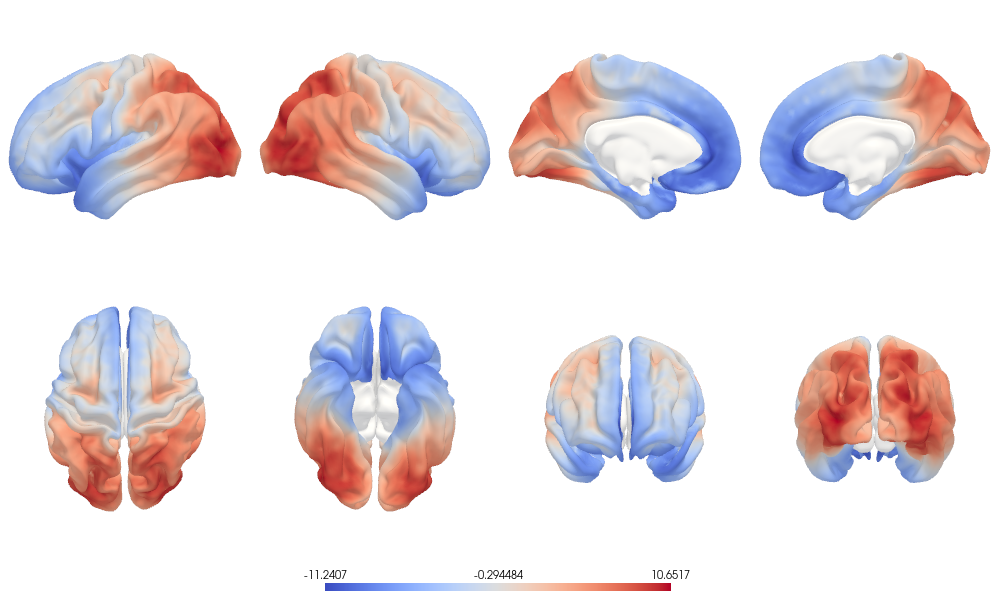

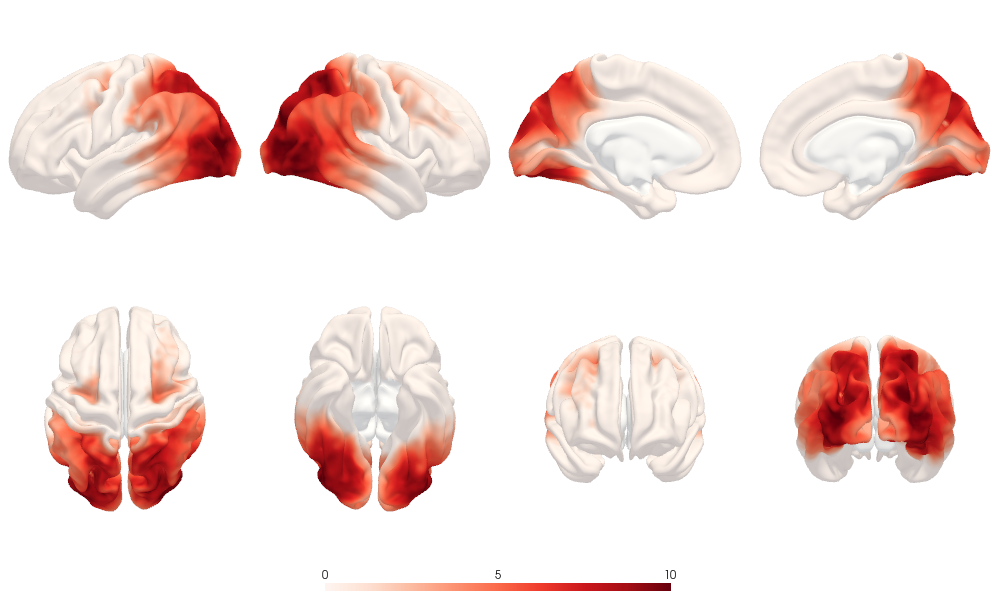

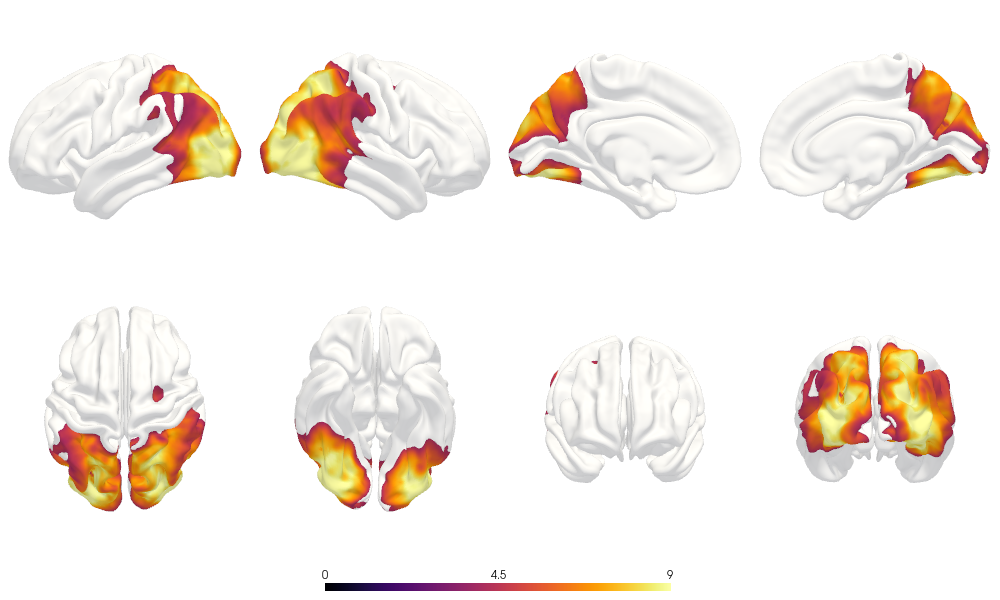

In [47]:
# fetch an example 3D volume data from neurovault
nv_url = "http://neurovault.org/media/images/4874/MNI152_EB_01.nii.gz"
nii_path = pooch.retrieve(url=nv_url, known_hash=None, path=pooch.os_cache("yabplot"), 
                          fname="sample_task_map.nii.gz")

# load the standard brain mesh paths
b_lh_path, b_rh_path = yab.data.get_surface_paths('midthickness', 'bmesh')

# project 3d volume to 1d surface arrays
lh_data, rh_data = yab.project_vol2surf(nii_path, bmesh='midthickness')

# make vertex-wise brain meshes with the injected data
lh_mesh, rh_mesh = yab.load_vertexwise_mesh(b_lh_path, b_rh_path, lh_data, rh_data)

# plot
yab.plot_vertexwise(lh_mesh, rh_mesh, cmap='coolwarm')

# plotting parameters are largely the same as in plot_cortical
yab.plot_vertexwise(lh_mesh, rh_mesh, cmap='Reds', vminmax=[0, 10])

# thresholding data before plotting
lh_data = np.where(lh_data > 4, lh_data, np.nan)
rh_data = np.where(rh_data > 4, rh_data, np.nan)
lh_mesh, rh_mesh = yab.load_vertexwise_mesh(b_lh_path, b_rh_path, lh_data, rh_data)
yab.plot_vertexwise(lh_mesh, rh_mesh, cmap='inferno', vminmax=[0, 9])

## 2. using custom brain mesh

NB! currently doesnt support medial wall masking when using custom brain mesh

/Users/to8050an/Documents/GitHub/yabplot/yabplot/projection.py:84: UserWarning: [WARNING] medial wall masking is only automatically supported for standard yabplot string meshes. skipping mask.
  warnings.warn("[WARNING] medial wall masking is only automatically supported for standard yabplot string meshes. skipping mask.")


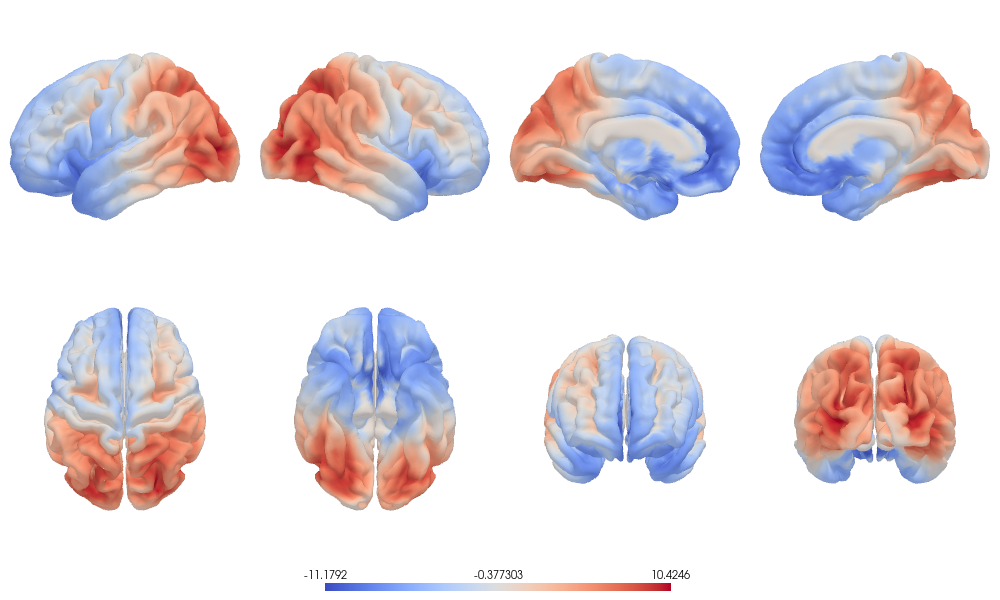

In [48]:
# fetch custom brain mesh, fsaverage5 in this example
lh_url = "https://raw.githubusercontent.com/nilearn/nilearn/main/nilearn/datasets/data/fsaverage5/pial_left.gii.gz"
rh_url = "https://raw.githubusercontent.com/nilearn/nilearn/main/nilearn/datasets/data/fsaverage5/pial_right.gii.gz"
lh_mesh_path = pooch.retrieve(url=lh_url, known_hash=None,
    path=pooch.os_cache("yabplot"), fname="fsaverage5_lh.pial.gii.gz")
rh_mesh_path = pooch.retrieve(url=rh_url, known_hash=None,
    path=pooch.os_cache("yabplot"), fname="fsaverage5_rh.pial.gii.gz")

# load the .gii.gz paths into pyvista PolyData objects
custom_bmesh = yab.mesh.load_bmesh({'L': lh_mesh_path, 'R': rh_mesh_path})

# use the same data to project
nv_url = "http://neurovault.org/media/images/4874/MNI152_EB_01.nii.gz"
nii_path = pooch.retrieve(url=nv_url, known_hash=None, 
    path=pooch.os_cache("yabplot_custom"), fname="sample_task_map.nii.gz")

# plot on custom brain mesh
lh_data, rh_data = yab.project_vol2surf(nii_path, bmesh=custom_bmesh)

# inject the projected 1D arrays directly into the pyvista meshes
lh_mesh = custom_bmesh['L']
lh_mesh['Data'] = lh_data
rh_mesh = custom_bmesh['R']
rh_mesh['Data'] = rh_data

# plot
yab.plot_vertexwise(
    lh=lh_mesh, 
    rh=rh_mesh, 
    cmap='coolwarm'
)